In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/")

from sklearn.metrics import roc_curve, roc_auc_score

RENAME     = {'cposedm': 'ocedm'}
RENAME_INV = {v: k for k, v in RENAME.items()}

ZHOU_SCORES = {
    'length': 0.8741, 'edm': 0.9736, 'fsd': 0.9271,
    'coverage': 0.9638, 'ends': 0.9639, 'ocf': 0.9467,
    'ifs': 0.9653, 'wps': 0.9658, 'pfe': 0.9579, 'fsr': 0.9441
}

FEATURE_NAMES = ['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf',
                 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm']

# Fixed colour map — same feature = same colour across all plots
_pal = sns.color_palette("tab20", len(FEATURE_NAMES))
FEATURE_COLORS = {f: _pal[i] for i, f in enumerate(FEATURE_NAMES)}
for _f in list(FEATURE_NAMES):
    FEATURE_COLORS[RENAME.get(_f, _f)] = FEATURE_COLORS[_f]

NEW_FEATURES = {'iedm', 'eedm', 'eoedm', 'ocedm'}   # novel contributions (post-rename)

def _fcolor(name):
    return FEATURE_COLORS.get(name, FEATURE_COLORS.get(RENAME_INV.get(name, name), '#888888'))

def _oldnew_color(name):
    """Blue = existing feature, red = novel feature."""
    return '#d62728' if name in NEW_FEATURES else '#1f77b4'


def load_roc_data(directory, feature_names=None, suffix='_probs.csv'):
    if feature_names is None:
        feature_names = FEATURE_NAMES
    roc_data, missing = [], []
    for feature in feature_names:
        path = os.path.join(directory, f"{feature}{suffix}")
        if not os.path.exists(path):
            missing.append(feature)
            continue
        df = pd.read_csv(path)[['probability', 'label']]
        fpr, tpr, _ = roc_curve(df['label'], df['probability'])
        auc = roc_auc_score(df['label'], df['probability'])
        roc_data.append({'name': RENAME.get(feature, feature), 'fpr': fpr, 'tpr': tpr, 'auc': auc})
    roc_data.sort(key=lambda x: x['auc'], reverse=True)
    if missing:
        print(f"Missing: {missing}")
    return roc_data


In [2]:
results_folder = "data/model_results/"
rbf_mapq0 = pd.read_csv(results_folder + "svm_rbf_cv1_cv_results.csv")
rbf_mapq15 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq15_cv_results.csv")
rbf_mapq30 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq30_cv_results.csv")
rbf_mapq45 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq45_cv_results.csv")
zhou_scores = pd.DataFrame({
    'length': 0.8741, 'edm': 0.9736, 'fsd': 0.9271,
    'coverage': 0.9638, 'ends': 0.9639, 'ocf': 0.9467,
    'ifs': 0.9653, 'wps': 0.9658, 'pfe': 0.9579, 'fsr': 0.9441
}, index=[0]).T.rename(columns={0: 'auc'})
zhou_scores.index.name = 'feature'


In [3]:
features = pd.DataFrame(FEATURE_NAMES, columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(rbf_mapq0[['feature', 'auc']].rename(columns={'auc': 'mapq0'}), on='feature', how='left')
auc_df = auc_df.merge(rbf_mapq15[['feature', 'auc']].rename(columns={'auc': 'mapq15'}), on='feature', how='left')
auc_df = auc_df.merge(rbf_mapq30[['feature', 'auc']].rename(columns={'auc': 'mapq30'}), on='feature', how='left')
auc_df = auc_df.merge(rbf_mapq45[['feature', 'auc']].rename(columns={'auc': 'mapq45'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')
auc_df

,feature,mapq0,mapq15,mapq30,mapq45,zhou
0,length,0.838868,0.831768,0.827131,0.818276,0.8741
1,fsd,0.919653,0.882457,0.881885,0.878259,0.9271
2,fsr,0.713310,0.709855,NaN,NaN,0.9441
3,pfe,0.861493,0.867858,0.866388,0.864060,0.9579
4,coverage,0.776528,0.759676,0.773455,0.763350,0.9638
5,ends,0.798695,0.796805,0.785832,0.792673,0.9639
6,ocf,0.836921,0.830404,0.819382,0.813428,0.9467
7,ifs,0.813485,0.803943,0.810355,0.805689,0.9653
8,wps,0.775373,0.779324,0.777205,0.775955,0.9658
9,edm,0.962556,0.967928,0.968892,0.966468,0.9736


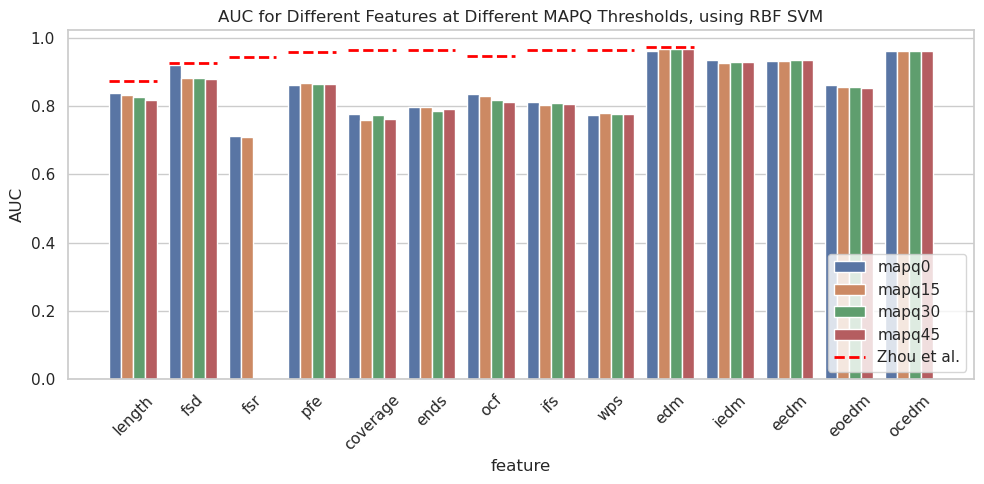

In [4]:
# bar plot of AUC distributions for different MAPQ thresholds
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(id_vars='feature', value_vars=['mapq0', 'mapq15', 'mapq30', 'mapq45'], var_name='mapq', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='mapq')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
plt.title('AUC for Different Features at Different MAPQ Thresholds, using RBF SVM')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/01_mapq.png")

In [5]:
linear_mapq30 = pd.read_csv(results_folder + "svm_linear_cv1_mapq30_cv_results.csv")
rbf_mapq30 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq30_cv_results.csv")
features = pd.DataFrame(['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm'], columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(rbf_mapq30[['feature', 'auc']].rename(columns={'auc': 'rbf'}), on='feature', how='left')
auc_df = auc_df.merge(linear_mapq30[['feature', 'auc']].rename(columns={'auc': 'linear'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')

# auc_df

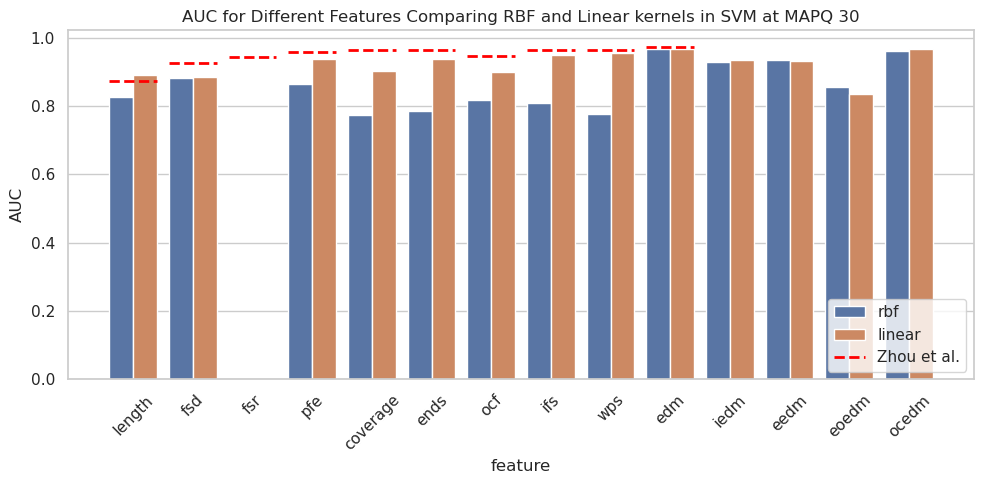

In [6]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(id_vars='feature', value_vars=['rbf', 'linear'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
plt.title('AUC for Different Features Comparing RBF and Linear kernels in SVM at MAPQ 30')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/02_kernel.png")

## PCA

In [7]:
linear_no_pca_mapq30 = pd.read_csv(results_folder + "svm_linear_cv1_mapq30_cv_results.csv")
linear_pca50_mapq30 = pd.read_csv(results_folder + "svm_linear_pca50.0_cv1_mapq30_cv_results.csv")
linear_pca100_mapq30 = pd.read_csv(results_folder + "svm_linear_pca100.0_cv1_mapq30_cv_results.csv")
linear_pca150_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_cv1_mapq30_cv_results.csv")
linear_pca200_mapq30 = pd.read_csv(results_folder + "svm_linear_pca200.0_cv1_mapq30_cv_results.csv")
features = pd.DataFrame(['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm'], columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(linear_pca50_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca50'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca100_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca100'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca150_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca150'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca200_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca200'}), on='feature', how='left')
auc_df = auc_df.merge(linear_no_pca_mapq30[['feature', 'auc']].rename(columns={'auc': 'no_pca'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')
auc_df

,feature,pca50,pca100,pca150,pca200,no_pca,zhou
0,length,0.873907,0.902554,0.899786,0.890187,0.891093,0.8741
1,fsd,0.876503,0.885368,0.870739,0.867075,0.886618,0.9271
2,fsr,0.412229,NaN,0.743254,NaN,NaN,0.9441
3,pfe,0.914367,0.930904,0.950666,0.931104,0.936811,0.9579
4,coverage,0.323257,0.627810,0.947565,0.945017,0.903164,0.9638
5,ends,0.227127,0.801977,0.946467,0.951115,0.937650,0.9639
6,ocf,0.382801,0.432459,0.902763,0.934091,0.900884,0.9467
7,ifs,0.291462,0.836883,0.952632,0.955676,0.950971,0.9653
8,wps,0.270449,0.638479,0.942259,0.949177,0.955895,0.9658
9,edm,0.950323,0.953529,0.958348,0.961487,0.967442,0.9736


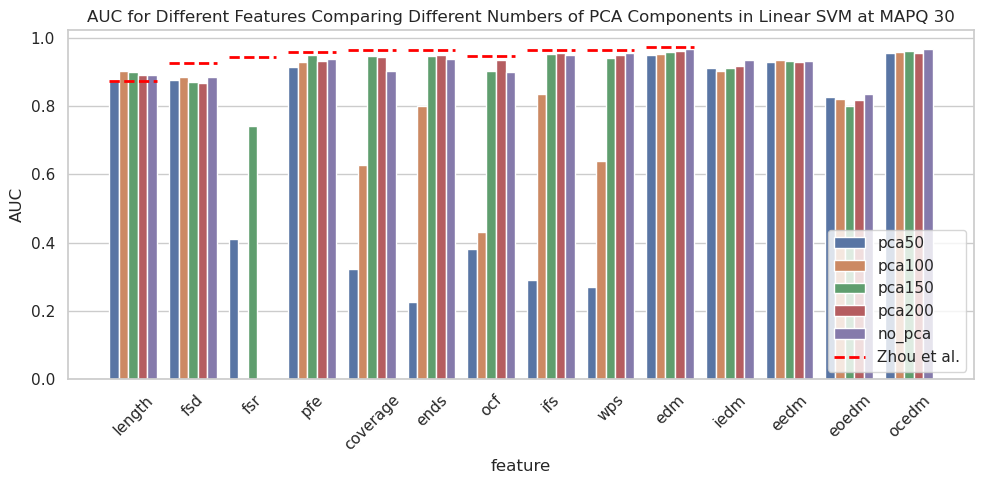

In [8]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(id_vars='feature', value_vars=['pca50', 'pca100', 'pca150', 'pca200', 'no_pca'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
plt.title('AUC for Different Features Comparing Different Numbers of PCA Components in Linear SVM at MAPQ 30')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/03_pca.png")

## GC Correction

In [9]:
linear_pca150_mapq30    = pd.read_csv(results_folder + "svm_linear_pca150.0_cv1_mapq30_cv_results.csv")
linear_pca150_gc_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_gc_cv1_mapq30_cv_results.csv")

auc_df = pd.DataFrame(FEATURE_NAMES, columns=['feature'])
auc_df = auc_df.merge(linear_pca150_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_false'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca150_gc_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_true'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')
auc_df

,feature,gc_false,gc_true,zhou
0,length,0.899786,0.899786,0.8741
1,fsd,0.870739,0.870739,0.9271
2,fsr,0.743254,0.743254,0.9441
3,pfe,0.950666,0.950198,0.9579
4,coverage,0.947565,0.915951,0.9638
5,ends,0.946467,0.939034,0.9639
6,ocf,0.902763,0.914291,0.9467
7,ifs,0.952632,0.940427,0.9653
8,wps,0.942259,0.955533,0.9658
9,edm,0.958348,0.958348,0.9736


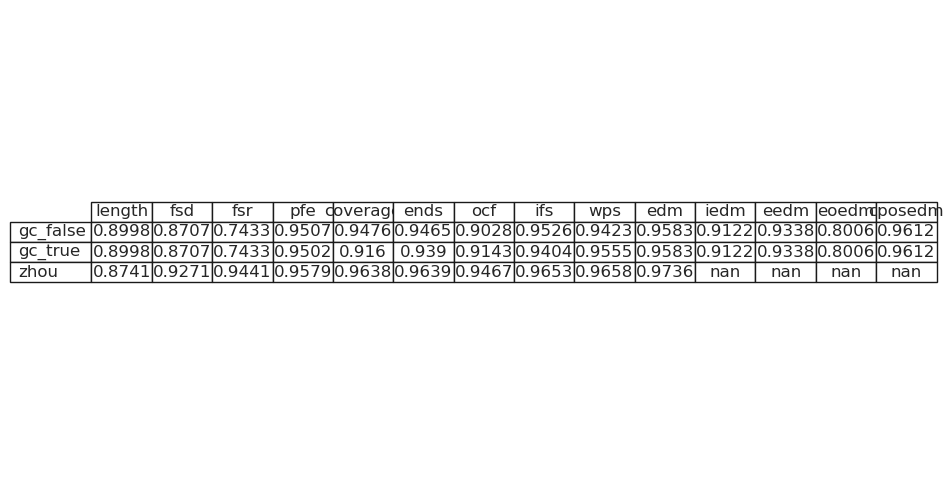

In [10]:
fig, ax = plt.subplots(figsize=(24, 5))
ax.axis('off')
table_data = auc_df[['feature', 'gc_false', 'gc_true', 'zhou']].round(4).T
col_labels = table_data.iloc[0].tolist()  # feature names as column headers
table_data = table_data.iloc[1:]          # drop the feature row
table = ax.table(
    cellText=table_data.values,
    colLabels=col_labels,
    rowLabels=table_data.index.tolist(),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2, 1)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig("scripts/analysis/04_gc_correction_table.png", facecolor='white')
plt.show()


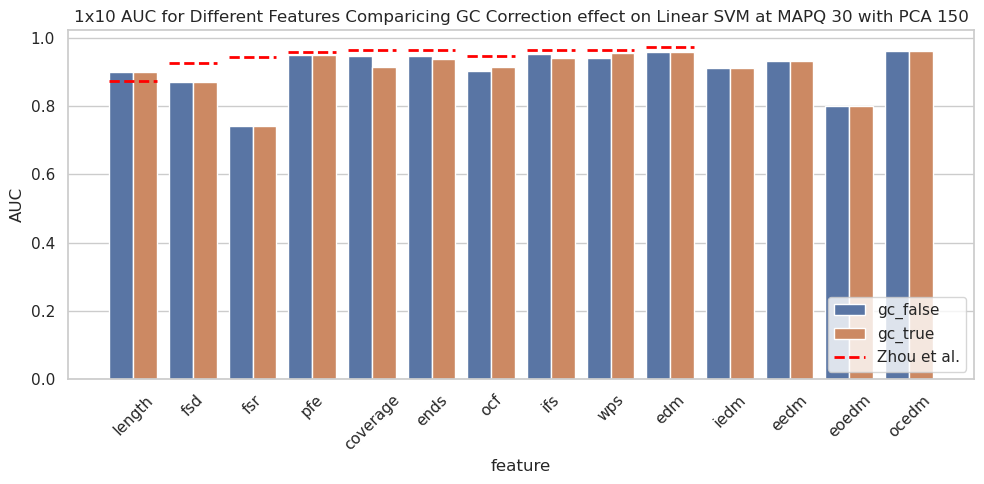

In [11]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(
    id_vars='feature',
    value_vars=['gc_false', 'gc_true'],
    var_name='Model',
    value_name='AUC'
)
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
plt.title('1x10 AUC for Different Features Comparicing GC Correction effect on Linear SVM at MAPQ 30 with PCA 150')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/04_gc_correction.png")

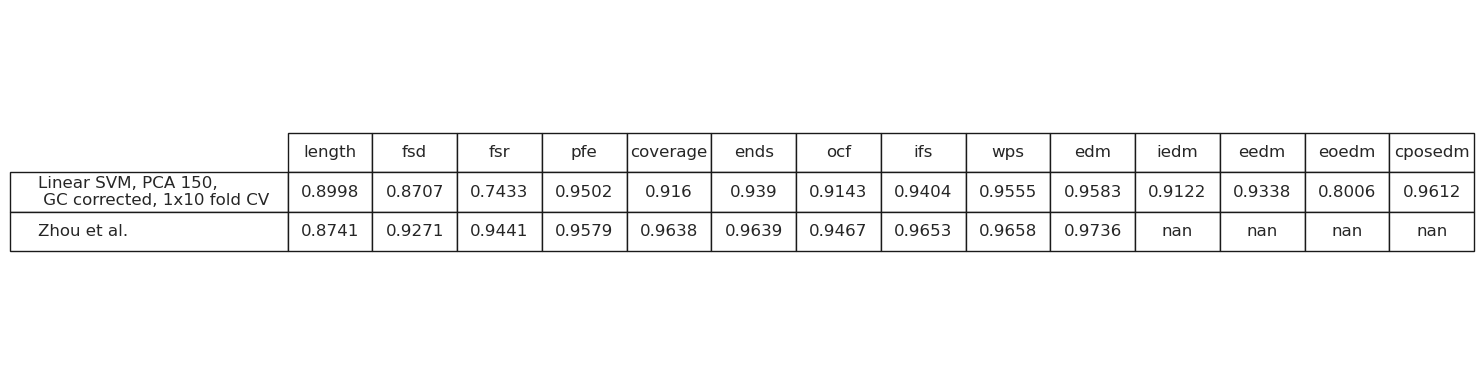

In [12]:
auc_tab = auc_df.set_index('feature')[['gc_true', 'zhou']].round(4).rename(columns={'gc_true': 'Linear SVM, PCA 150,\n GC corrected, 1x10 fold CV', 'zhou': 'Zhou et al.'}).T
fig, ax = plt.subplots(figsize=(15, 4))
ax.axis('off')
table = ax.table(
    cellText=auc_tab.values,
    colLabels=auc_tab.columns,
    rowLabels=auc_tab.index.tolist(),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
plt.tight_layout()
plt.savefig("scripts/analysis/04_gc_correction_table.png", facecolor='white') 

<Figure size 640x480 with 0 Axes>

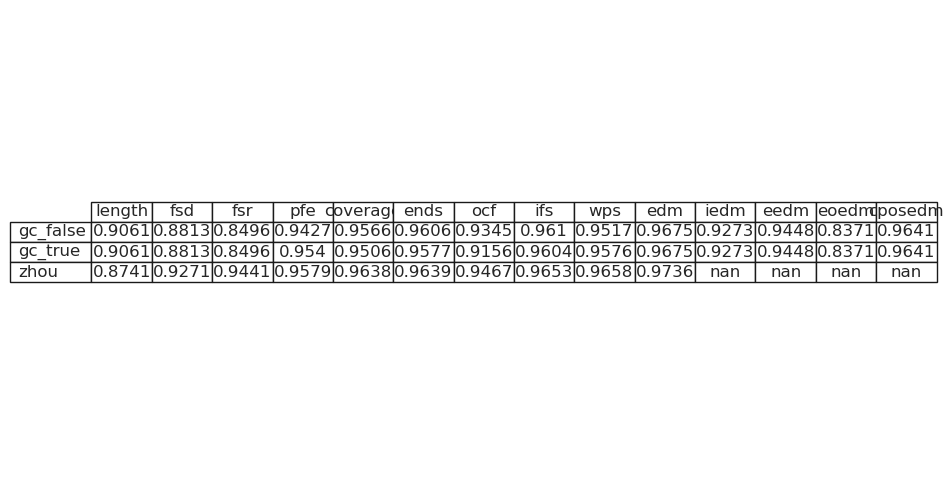

In [13]:
# 10 x 10 cv results for all features, linear kernel, mapq30, pca150, gc correction true vs false
linear_pca150_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_mapq30_cv_results.csv")
linear_pca150_gc_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_gc_mapq30_cv_results.csv")
features = pd.DataFrame(['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm'], columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(linear_pca150_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_false'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca150_gc_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_true'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')
auc_df
plt.figure()
auc_tab = auc_df.T
fig, ax = plt.subplots(figsize=(24, 5))
ax.axis('off')
table_data = auc_df[['feature', 'gc_false', 'gc_true', 'zhou']].round(4).T
col_labels = table_data.iloc[0].tolist()  # feature names as column headers
table_data = table_data.iloc[1:]          # drop the feature row
table = ax.table(
    cellText=table_data.values,
    colLabels=col_labels,
    rowLabels=table_data.index.tolist(),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2, 1)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig("scripts/analysis/05_gc_cv10_table.png", facecolor='white')
plt.show()


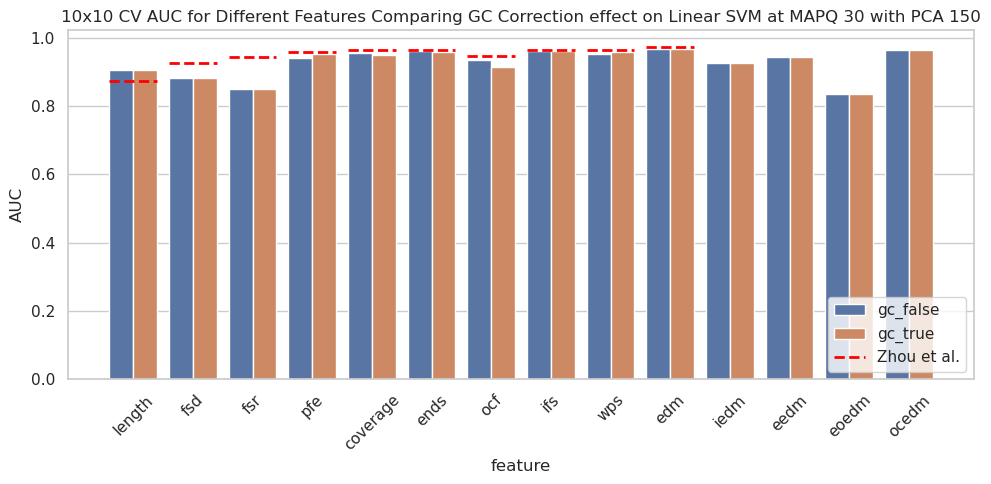

In [14]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(
    id_vars='feature',
    value_vars=['gc_false', 'gc_true'],
    var_name='Model',
    value_name='AUC'
)
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
plt.title('10x10 CV AUC for Different Features Comparing GC Correction effect on Linear SVM at MAPQ 30 with PCA 150')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/05_gc_cv10.png")

## TODO

- ROC curves — full curves for CV and external test sets (best config), no CI
- Score distributions — violin/box plots of predicted probability, cancer vs healthy, per feature
- Feature correlation heatmap — correlation of predicted probabilities across features (motivates ensemble)
- Stage-stratified AUC — Cristiano stage I/II/III/IV; use stage info from manifest
- Cross-dataset heatmap — feature × dataset AUC matrix (Cristiano/CRC train × LY/GeoScan test), once external validation complete

In [15]:
# ══════════════════════════════════════════════════════════════════════
# PLOT TODO LIST
# Colour rules: per-feature plots use _fcolor(name) for consistent colours.
#               Old/new variant: _oldnew_color(name) (blue=existing, red=novel).
#
# B — Cristiano 10×10 CV (per-feature)
#   B5.  Feature correlation heatmap
#   B6.  ROC curves, all features          → B6_roc_cv.png
#   B7.  AUC bars vs Zhou                  → B7_auc_cv.png
#   B7b. AUC bars old/new variant          → B7b_auc_oldnew_cv.png
#   B8.  Score distributions (violin)      → B8_score_dist_cv.png
#   B9.  Stage-stratified AUC line         → B9_stage_auc_cv.png
#
# C — Cristiano ensemble (meta-matrix trained on Cristiano)
#   C_data.  Load ensemble_nostd CV probs + manifest; define cv_roc, ens_merge
#   C10. ROC per-feature (faded) + ensemble bold black  → C10_roc_ensemble_cv.png
#   C11. AUC bars per-feature + ensemble                → C11_auc_bars_ensemble_cv.png
#   C11b.AUC bars old/new variant (no ensemble bar)     → C11b_auc_oldnew_cv.png
#   C12. ROC by cancer type — 3×3 grid                  → C12_roc_cancer_type_grid.png
#   C13. ROC by stage I/II/III/IV                       → C13_roc_stage_ensemble.png
#   C13b.Stage AUC line plot (ensemble)                 → C13b_stage_auc_ensemble.png
#
# D — External validation (2-panel ROC+AUC per condition + old/new variant)
#   D14/14b. Cristiano → LY          → D14_crist_ly.png / D14b_oldnew.png
#   D15/15b. Cristiano → GS          → D15_crist_gs.png / D15b_oldnew.png
#   D16/16b. CRC CV                  → D16_crc_cv.png   / D16b_oldnew.png
#   D16c.    CRC stage AUC line      → D16c_crc_stage_auc.png
#   D17/17b. CRC → LY                → D17_crc_ly.png   / D17b_oldnew.png
#   D18/18b. CRC → GS                → D18_crc_gs.png   / D18b_oldnew.png
#   D19/19b. LY CV                   → D19_ly_cv.png    / D19b_oldnew.png
#   D20/20b. LY → LY                 → D20_ly_ly.png    / D20b_oldnew.png
#   D21/21b. LY → GS                 → D21_ly_gs.png    / D21b_oldnew.png
#
# E — Summary
#   E22. Cross-dataset AUC heatmap (feature × 9 conditions)  → E22_auc_heatmap.png
# ══════════════════════════════════════════════════════════════════════


## B — Cristiano 10×10 CV (per-feature)

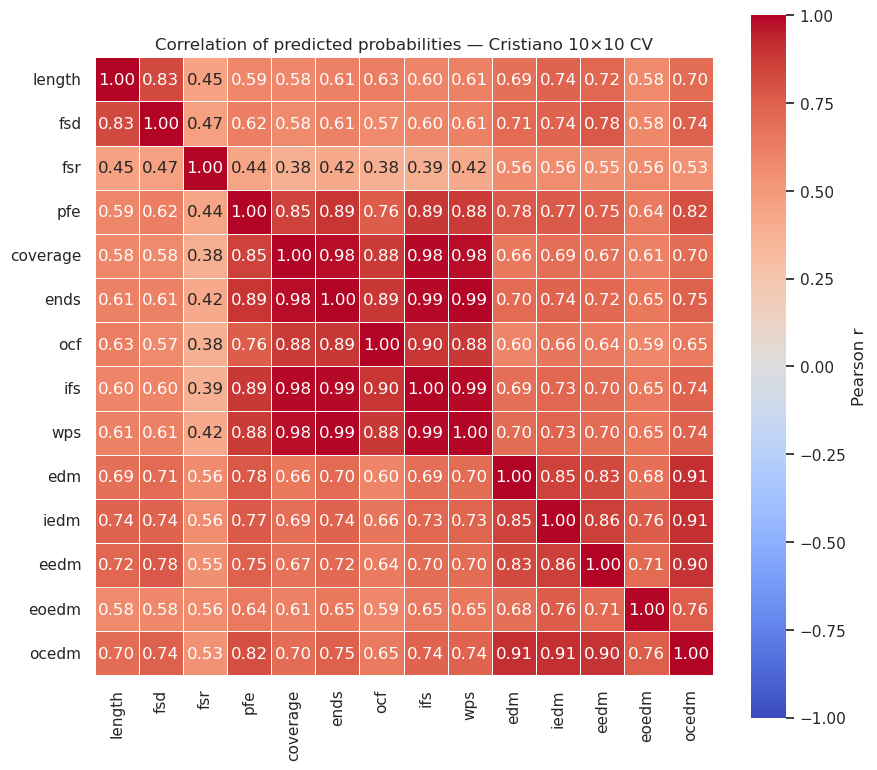

In [16]:
cv_dir  = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
manifest = pd.read_csv("data/manifest/Cristiano_metadata.csv")[['sample_id', 'disease', 'stage']]

probs_wide = None
for feature in FEATURE_NAMES:
    path = cv_dir + f"{feature}_cv_probs.csv"
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)[['sample_id', 'probability']].rename(columns={'probability': feature})
    probs_wide = df if probs_wide is None else probs_wide.merge(df, on='sample_id')

corr = probs_wide.drop(columns='sample_id').rename(columns=RENAME).corr()
plt.figure(figsize=(9, 8))
sns.set_theme(style="white")
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation of predicted probabilities — Cristiano 10×10 CV')
plt.tight_layout()
plt.savefig("scripts/analysis/B5_feature_corr.png")
plt.show()


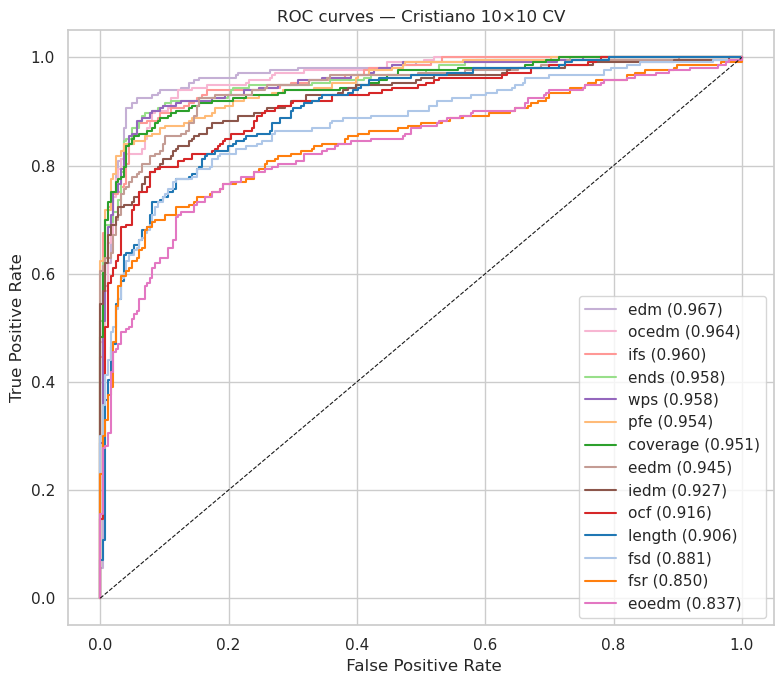

In [64]:
cv_roc = load_roc_data(cv_dir, suffix='_cv_probs.csv')

fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in cv_roc:
    ax.plot(d['fpr'], d['tpr'], color=_fcolor(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel(' False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves — Cristiano 10×10 CV')
ax.legend()
plt.tight_layout()
plt.savefig("scripts/analysis/B6_roc_cv.png", bbox_inches='tight')
plt.show()


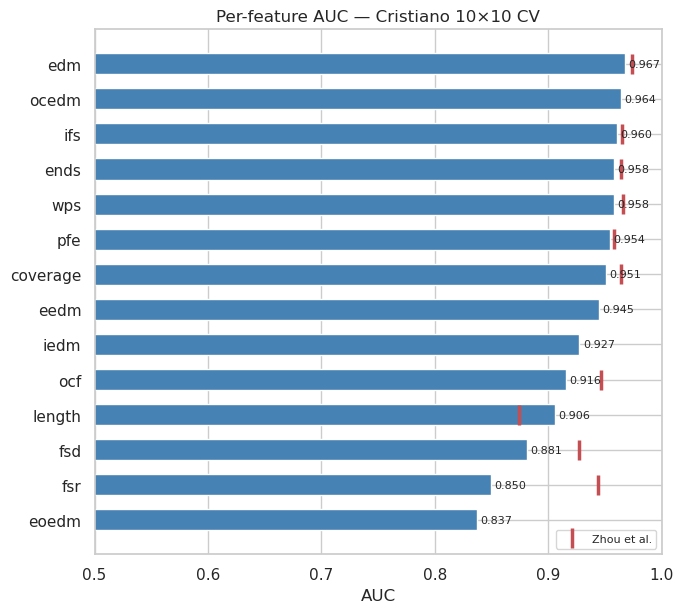

In [26]:
names = [d['name'] for d in cv_roc]
aucs  = [d['auc']  for d in cv_roc]

fig, ax = plt.subplots(figsize=(7, max(4, len(names) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names)), aucs, color='steelblue', height=0.6)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.invert_yaxis(); ax.set_xlim(0.5, 1.0); ax.set_xlabel('AUC')
ax.set_title('Per-feature AUC — Cristiano 10×10 CV')
for i, n in enumerate(names):
    z = ZHOU_SCORES.get(RENAME_INV.get(n, n))
    if z is not None:
        ax.plot(z, i, 'r|', markersize=14, markeredgewidth=2.5,
                label='Zhou et al.' if i == 0 else '')
ax.legend(loc='lower right', fontsize=8)
for i, a in enumerate(aucs):
    ax.text(a + 0.003, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/B7_auc_cv.png", bbox_inches='tight')
plt.show()

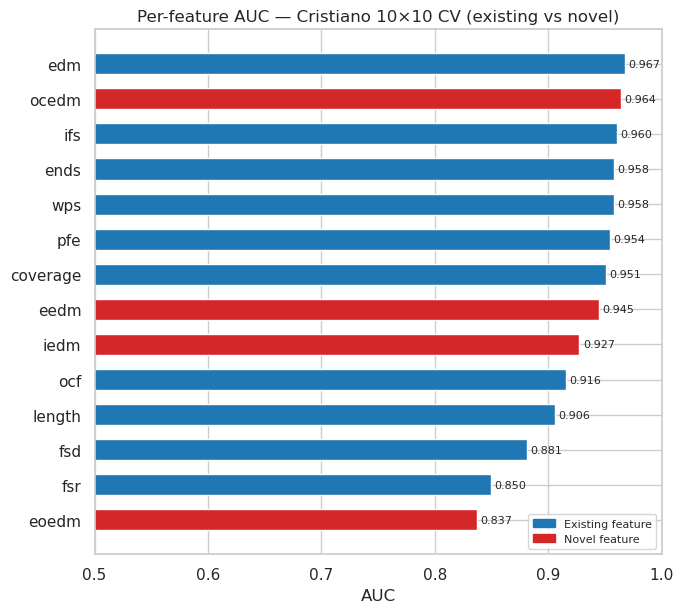

In [63]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, max(4, len(names) * 0.45)))
sns.set_theme(style="whitegrid")
ax.barh(range(len(names)), aucs, color=[_oldnew_color(n) for n in names], height=0.6)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.invert_yaxis(); ax.set_xlim(0.5, 1.0); ax.set_xlabel('AUC')
ax.set_title('Per-feature AUC — Cristiano 10×10 CV (existing vs novel)')

ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for i, a in enumerate(aucs):
    ax.text(a + 0.003, i, f'{a:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/B7b_auc_oldnew_cv.png", bbox_inches='tight')
plt.show()


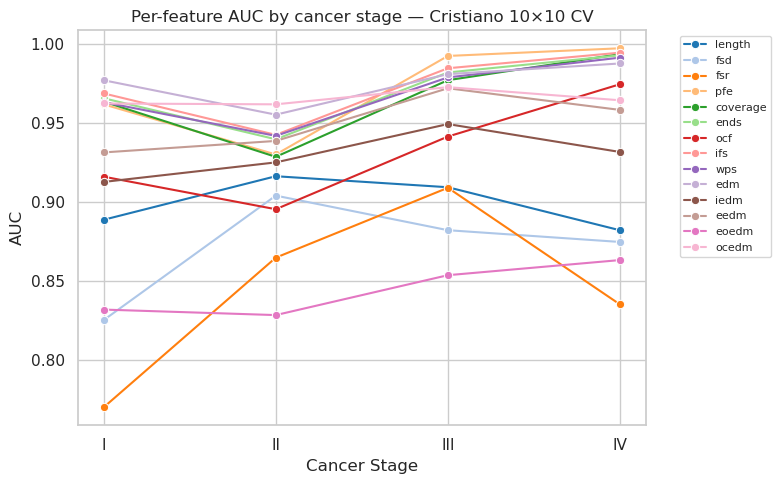

In [21]:
records = []
for feature in FEATURE_NAMES:
    path = cv_dir + f"{feature}_cv_probs.csv"
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)[['sample_id', 'probability', 'label']].merge(manifest, on='sample_id', how='left')
    healthy = df[df['disease'] == 'Healthy']
    for stage in ['I', 'II', 'III', 'IV']:
        cancer = df[(df['label'] == 1) & (df['stage'] == stage)]
        if len(cancer) == 0:
            continue
        subset = pd.concat([cancer, healthy])
        auc = roc_auc_score(subset['label'], subset['probability'])
        records.append({'feature': RENAME.get(feature, feature), 'stage': stage, 'auc': auc, 'n': len(cancer)})
stage_auc = pd.DataFrame(records)

palette = {RENAME.get(f, f): _fcolor(RENAME.get(f, f)) for f in FEATURE_NAMES}
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
sns.lineplot(data=stage_auc, x='stage', y='auc', hue='feature', marker='o', palette=palette)
plt.xlabel('Cancer Stage'); plt.ylabel('AUC')
plt.title('Per-feature AUC by cancer stage — Cristiano 10×10 CV')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/B9_stage_auc_cv.png", bbox_inches='tight')
plt.show()


## C — Cristiano ensemble

In [58]:
ens_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/ensemble_nostd/cv/"
ens_df = pd.read_csv(ens_dir + "cv_probs.csv")
# index column is unnamed, name as sample_id
ens_df = ens_df.rename(columns={'Unnamed: 0': 'sample_id'})

ens_fpr, ens_tpr, _ = roc_curve(ens_df['label'], ens_df['probability'])
ens_auc = roc_auc_score(ens_df['label'], ens_df['probability'])
ens_merge = ens_df[['sample_id', 'probability', 'label']].merge(manifest, on='sample_id', how='left')
print(f"Ensemble AUC: {ens_auc:.4f}  (n={len(ens_df)})")

Ensemble AUC: 0.9918  (n=459)


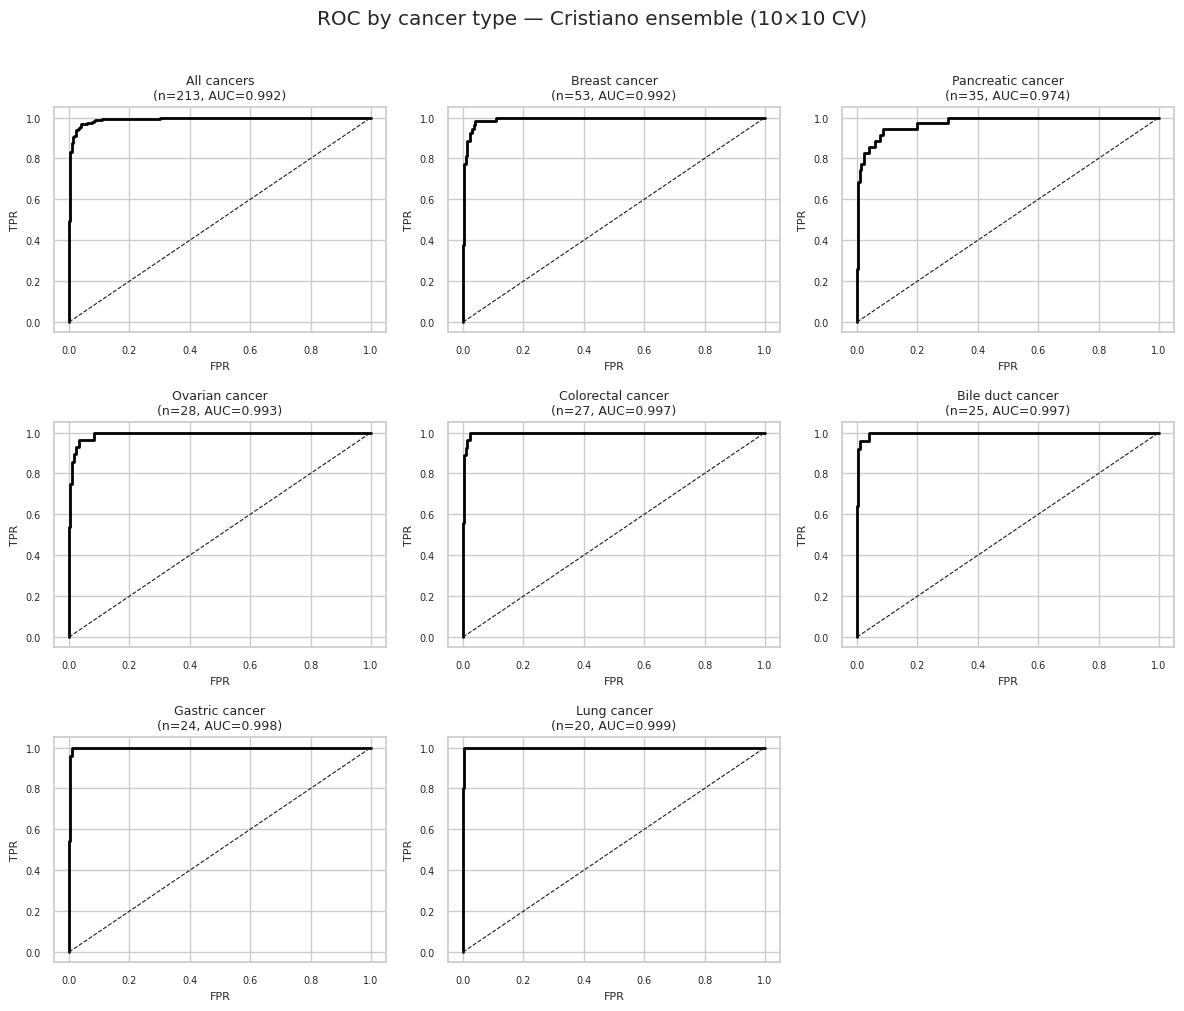

In [61]:
cancer_types = (ens_merge[ens_merge['label'] == 1]['disease']
                .value_counts()
                .loc[lambda s: s >= 5].index.tolist())
healthy = ens_merge[ens_merge['disease'] == 'Healthy']
panels  = ['All cancers'] + cancer_types

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
sns.set_theme(style="whitegrid")
for i, ax in enumerate(axes.flatten()):
    if i >= len(panels):
        ax.set_visible(False)
        continue
    if panels[i] == 'All cancers':
        cancer = ens_merge[ens_merge['label'] == 1]
    else:
        cancer = ens_merge[ens_merge['disease'] == panels[i]]
    subset = pd.concat([cancer, healthy])
    fpr_t, tpr_t, _ = roc_curve(subset['label'], subset['probability'])
    auc_t = roc_auc_score(subset['label'], subset['probability'])
    ax.plot(fpr_t, tpr_t, color='black', lw=2)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f"{panels[i]}\n(n={len(cancer)}, AUC={auc_t:.3f})", fontsize=9)
    ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle('ROC by cancer type — Cristiano ensemble (10×10 CV)', y=1.01)
plt.tight_layout()
plt.savefig("scripts/analysis/C12_roc_cancer_type_grid.png", bbox_inches='tight')
plt.show()

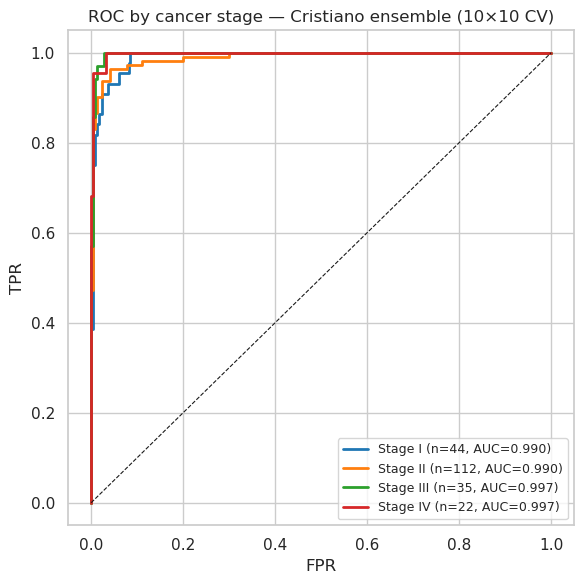

In [62]:
stage_colors = {'I': '#1f77b4', 'II': '#ff7f0e', 'III': '#2ca02c', 'IV': '#d62728'}
healthy_ens  = ens_merge[ens_merge['disease'] == 'Healthy']

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_theme(style="whitegrid")
for stage in ['I', 'II', 'III', 'IV']:
    cancer = ens_merge[(ens_merge['label'] == 1) & (ens_merge['stage'] == stage)]
    if len(cancer) == 0:
        continue
    subset = pd.concat([cancer, healthy_ens])
    fpr_s, tpr_s, _ = roc_curve(subset['label'], subset['probability'])
    auc_s = roc_auc_score(subset['label'], subset['probability'])
    ax.plot(fpr_s, tpr_s, color=stage_colors[stage], lw=2,
            label=f"Stage {stage} (n={len(cancer)}, AUC={auc_s:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC by cancer stage — Cristiano ensemble (10×10 CV)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/C13_roc_stage_ensemble.png", bbox_inches='tight')
plt.show()